In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

from xgboost import XGBRegressor

import shap

In [2]:
from pathlib import Path

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent.parent
PROCESSED_DIR = PROJECT_ROOT / "Data" / "Processed"

print(PROCESSED_DIR)

C:\Users\Sameen\10 Pearls Project\AQI Predictor\Data\Processed


In [3]:
df = pd.read_csv(PROCESSED_DIR / "Aqi_Data_Two_Day_Prediction_New.csv", index_col="time", parse_dates=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26208 entries, 2023-08-04 00:00:00+05:00 to 2026-07-30 23:00:00+05:00
Data columns (total 50 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   temperature_2m             26208 non-null  float64
 1   wind_speed_10m             26208 non-null  float64
 2   relative_humidity_2m       26208 non-null  int64  
 3   surface_pressure           26208 non-null  float64
 4   boundary_layer_height      21840 non-null  float64
 5   dew_point_2m               26208 non-null  float64
 6   precipitation              26208 non-null  float64
 7   cloud_cover                26208 non-null  int64  
 8   wind_direction_10m         26208 non-null  int64  
 9   wind_gusts_10m             26208 non-null  float64
 10  shortwave_radiation        26208 non-null  float64
 11  pm10                       26208 non-null  float64
 12  pm2_5                      26208 non-null  float64
 13 

In [4]:
df.head()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f48_surface_pressure,f48_boundary_layer_height,f48_dew_point_2m,f48_precipitation,f48_cloud_cover,f48_wind_gusts_10m,f48_shortwave_radiation,wind_pollution_dispersion,pressure_change_3hour,Humidity_Level
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+05:00,27.4,18.7,90,1000.1,785.0,25.5,0.0,24,251,26.6,...,1003.5,870.0,24.6,0.0,92.0,28.8,0.0,14679.5,0.2,1.9
2023-08-04 01:00:00+05:00,27.2,19.0,90,999.3,810.0,25.5,0.0,23,255,27.0,...,1002.7,820.0,24.7,0.0,42.0,32.0,0.0,15390.0,-0.9,1.7
2023-08-04 02:00:00+05:00,27.0,17.7,92,998.6,790.0,25.5,0.0,19,257,27.4,...,1002.1,825.0,24.7,0.0,53.0,33.8,0.0,13983.0,-1.7,1.5
2023-08-04 03:00:00+05:00,26.9,17.1,92,998.7,845.0,25.5,0.0,49,255,25.2,...,1001.9,880.0,24.8,0.0,20.0,36.4,0.0,14449.5,-1.4,1.4
2023-08-04 04:00:00+05:00,27.0,20.0,92,998.8,830.0,25.5,0.0,33,262,28.4,...,1001.9,855.0,24.9,0.0,44.0,37.4,0.0,16600.0,-0.5,1.5


# Train And Test Split

In [5]:
df.columns

Index(['temperature_2m', 'wind_speed_10m', 'relative_humidity_2m',
       'surface_pressure', 'boundary_layer_height', 'dew_point_2m',
       'precipitation', 'cloud_cover', 'wind_direction_10m', 'wind_gusts_10m',
       'shortwave_radiation', 'pm10', 'pm2_5', 'carbon_monoxide',
       'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust',
       'aerosol_optical_depth', 'us_aqi', 'hour', 'day', 'month', 'dayofweek',
       'quarter', 'previous_hour_aqi', 'previous_day_aqi', 'aqi_change_rate',
       'rolled_mean_aqi_6hr', 'rolled_mean_aqi_24hr', 'rolled_mean_aqi_72hr',
       'rolled_std_aqi_6hr', 'rolled_std_aqi_24hr', 'rolled_std_aqi_72hr',
       'ewm_aqi_24hr', 'ewm_std_24hr', 'Day_2_Future_AQI',
       'f48_temperature_2m', 'f48_wind_speed_10m', 'f48_relative_humidity_2m',
       'f48_surface_pressure', 'f48_boundary_layer_height', 'f48_dew_point_2m',
       'f48_precipitation', 'f48_cloud_cover', 'f48_wind_gusts_10m',
       'f48_shortwave_radiation', 'wind_pollution_dispersion

In [6]:
X = df.drop(columns = ['Day_2_Future_AQI'])
Y = df['Day_2_Future_AQI']

In [7]:
X

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f48_surface_pressure,f48_boundary_layer_height,f48_dew_point_2m,f48_precipitation,f48_cloud_cover,f48_wind_gusts_10m,f48_shortwave_radiation,wind_pollution_dispersion,pressure_change_3hour,Humidity_Level
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+05:00,27.4,18.7,90,1000.1,785.0,25.5,0.0,24,251,26.6,...,1003.5,870.0,24.6,0.0,92.0,28.8,0.0,14679.5,0.2,1.9
2023-08-04 01:00:00+05:00,27.2,19.0,90,999.3,810.0,25.5,0.0,23,255,27.0,...,1002.7,820.0,24.7,0.0,42.0,32.0,0.0,15390.0,-0.9,1.7
2023-08-04 02:00:00+05:00,27.0,17.7,92,998.6,790.0,25.5,0.0,19,257,27.4,...,1002.1,825.0,24.7,0.0,53.0,33.8,0.0,13983.0,-1.7,1.5
2023-08-04 03:00:00+05:00,26.9,17.1,92,998.7,845.0,25.5,0.0,49,255,25.2,...,1001.9,880.0,24.8,0.0,20.0,36.4,0.0,14449.5,-1.4,1.4
2023-08-04 04:00:00+05:00,27.0,20.0,92,998.8,830.0,25.5,0.0,33,262,28.4,...,1001.9,855.0,24.9,0.0,44.0,37.4,0.0,16600.0,-0.5,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-30 19:00:00+05:00,29.7,10.7,81,995.5,460.0,26.0,0.0,91,224,33.8,...,997.3,545.0,25.3,0.0,98.0,35.6,42.0,4922.0,0.3,3.7
2026-07-30 20:00:00+05:00,29.2,9.6,84,996.0,425.0,26.2,0.0,91,227,27.4,...,997.9,530.0,25.2,0.0,99.0,30.2,1.0,4080.0,0.9,3.0
2026-07-30 21:00:00+05:00,29.1,8.3,84,996.5,425.0,26.2,0.0,84,229,24.1,...,998.4,490.0,25.2,0.0,100.0,29.9,0.0,3527.5,1.4,2.9


In [8]:
Y

time
2023-08-04 00:00:00+05:00    77.0
2023-08-04 01:00:00+05:00    77.0
2023-08-04 02:00:00+05:00    78.0
2023-08-04 03:00:00+05:00    79.0
2023-08-04 04:00:00+05:00    79.0
                             ... 
2026-07-30 19:00:00+05:00    89.0
2026-07-30 20:00:00+05:00    88.0
2026-07-30 21:00:00+05:00    88.0
2026-07-30 22:00:00+05:00    88.0
2026-07-30 23:00:00+05:00    88.0
Name: Day_2_Future_AQI, Length: 26208, dtype: float64

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle = False)

In [10]:
len(X_train)

20966

In [11]:
len(X_test)

5242

# Building XGBoost Model For Day Two

In [12]:
model = XGBRegressor(n_estimators = 520, 
                     learning_rate = 0.033,
                     max_depth = 3, 
                     random_state = 42, 
                     colsample_bytree = 0.7, 
                     subsample = 0.7,
                     min_child_weight = 5,
                     gamma=0.1,
                     reg_alpha=0.1,
                     reg_lambda=1.5,
                    ) 

In [13]:
model.fit(X_train, Y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [14]:
y_pred = model.predict(X_test)

# Evaluating the Model

In [15]:
R2_Score = r2_score(Y_test, y_pred)
Mae = mean_absolute_error(Y_test, y_pred)
Mean_Square_Error = mean_squared_error(Y_test, y_pred)
Root_Mean_Square_Error = np.sqrt(Mean_Square_Error)

print("Evaluation Metrics: ")
print(f"R2 Score: {R2_Score}")
print(f"Mean Absolute Error: {Mae}")
print(f"Mean Square Error: {Mean_Square_Error}")
print(f"Root Mean Square Error: {Root_Mean_Square_Error}")

Evaluation Metrics: 
R2 Score: 0.349388412263519
Mean Absolute Error: 11.754038276948895
Mean Square Error: 261.56141949635736
Root Mean Square Error: 16.172860584830296


# Note:
- Not much Improvement will come even if I do hyper parameter optimization. I will try other method

# Now Day Wise

In [16]:
day2 = pd.read_csv(PROCESSED_DIR / "Cyclic_Day_Two_AQI.csv", index_col="time", parse_dates=True)
day2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1090 entries, 2023-08-04 00:00:00+05:00 to 2026-07-28 00:00:00+05:00
Data columns (total 52 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   temperature_2m               1090 non-null   float64
 1   wind_speed_10m               1090 non-null   float64
 2   relative_humidity_2m         1090 non-null   float64
 3   surface_pressure             1090 non-null   float64
 4   boundary_layer_height        909 non-null    float64
 5   dew_point_2m                 1090 non-null   float64
 6   precipitation                1090 non-null   float64
 7   cloud_cover                  1090 non-null   float64
 8   wind_direction_10m           1090 non-null   float64
 9   wind_gusts_10m               1090 non-null   float64
 10  shortwave_radiation          1090 non-null   float64
 11  pm10                         1090 non-null   float64
 12  pm2_5                       

In [17]:
day2.head()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,Day_2_Future_AQI,cyclic_day_sin,cyclic_day_cos,cyclic_week_sin,cyclic_week_cos,delta_temperature_2m,delta_wind_speed_10m,delta_surface_pressure,delta_relative_humidity_2m,delta_boundary_layer_height
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+05:00,28.441667,20.516667,83.458333,1000.087500,752.708333,25.291667,0.037500,50.083333,245.083333,31.941667,...,78.833333,-0.545240,-0.838280,-0.433884,-0.900969,-0.208333,10.162500,1.520833,-3.083333,147.708333
2023-08-05 00:00:00+05:00,28.329167,21.941667,81.750000,1002.600000,818.333333,24.866667,0.037500,69.833333,247.750000,33.450000,...,78.875000,-0.559589,-0.828770,-0.974928,-0.222521,-0.287500,11.279167,-3.608333,-1.541667,98.125000
2023-08-06 00:00:00+05:00,28.233333,30.679167,80.375000,1001.608333,900.416667,24.479167,0.029167,81.625000,254.500000,45.562500,...,78.791667,-0.573772,-0.819015,-0.781831,0.623490,-0.237500,-1.250000,-2.245833,1.291667,-95.000000
2023-08-07 00:00:00+05:00,28.041667,33.220833,80.208333,998.991667,916.458333,24.266667,0.070833,75.000000,250.250000,49.770833,...,73.416667,-0.587785,-0.809017,0.000000,1.000000,-0.070833,-4.783333,3.595833,1.416667,-117.708333
2023-08-08 00:00:00+05:00,27.995833,29.429167,81.666667,999.362500,805.416667,24.512500,0.091667,68.541667,245.916667,44.275000,...,68.791667,-0.601624,-0.798779,0.781831,0.623490,-0.166667,-1.858333,4.245833,0.791667,-29.375000


In [18]:
day2.columns

Index(['temperature_2m', 'wind_speed_10m', 'relative_humidity_2m',
       'surface_pressure', 'boundary_layer_height', 'dew_point_2m',
       'precipitation', 'cloud_cover', 'wind_direction_10m', 'wind_gusts_10m',
       'shortwave_radiation', 'pm10', 'pm2_5', 'carbon_monoxide',
       'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust',
       'aerosol_optical_depth', 'us_aqi', 'month', 'dayofweek',
       'previous_day_aqi', 'rolled_mean_aqi_24hr', 'rolled_mean_aqi_72hr',
       'rolled_std_aqi_24hr', 'rolled_std_aqi_72hr', 'ewm_aqi_24hr',
       'ewm_std_24hr', 'f48_temperature_2m', 'f48_wind_speed_10m',
       'f48_relative_humidity_2m', 'f48_surface_pressure',
       'f48_boundary_layer_height', 'f48_dew_point_2m', 'f48_precipitation',
       'f48_cloud_cover', 'f48_wind_gusts_10m', 'f48_shortwave_radiation',
       'wind_pollution_dispersion', 'pressure_change_3hour', 'Humidity_Level',
       'Day_2_Future_AQI', 'cyclic_day_sin', 'cyclic_day_cos',
       'cyclic_week_sin', 'cy

In [19]:
X1 = day2.drop(columns = ['Day_2_Future_AQI'])
Y1 = day2['Day_2_Future_AQI']

In [20]:
X1

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,Humidity_Level,cyclic_day_sin,cyclic_day_cos,cyclic_week_sin,cyclic_week_cos,delta_temperature_2m,delta_wind_speed_10m,delta_surface_pressure,delta_relative_humidity_2m,delta_boundary_layer_height
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+05:00,28.441667,20.516667,83.458333,1000.087500,752.708333,25.291667,0.037500,50.083333,245.083333,31.941667,...,3.150000,-0.545240,-0.838280,-0.433884,-0.900969,-0.208333,10.162500,1.520833,-3.083333,147.708333
2023-08-05 00:00:00+05:00,28.329167,21.941667,81.750000,1002.600000,818.333333,24.866667,0.037500,69.833333,247.750000,33.450000,...,3.462500,-0.559589,-0.828770,-0.974928,-0.222521,-0.287500,11.279167,-3.608333,-1.541667,98.125000
2023-08-06 00:00:00+05:00,28.233333,30.679167,80.375000,1001.608333,900.416667,24.479167,0.029167,81.625000,254.500000,45.562500,...,3.754167,-0.573772,-0.819015,-0.781831,0.623490,-0.237500,-1.250000,-2.245833,1.291667,-95.000000
2023-08-07 00:00:00+05:00,28.041667,33.220833,80.208333,998.991667,916.458333,24.266667,0.070833,75.000000,250.250000,49.770833,...,3.775000,-0.587785,-0.809017,0.000000,1.000000,-0.070833,-4.783333,3.595833,1.416667,-117.708333
2023-08-08 00:00:00+05:00,27.995833,29.429167,81.666667,999.362500,805.416667,24.512500,0.091667,68.541667,245.916667,44.275000,...,3.483333,-0.601624,-0.798779,0.781831,0.623490,-0.166667,-1.858333,4.245833,0.791667,-29.375000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-24 00:00:00+05:00,30.233333,9.304167,76.625000,997.970833,503.958333,25.545833,0.000000,77.375000,233.250000,26.816667,...,4.687500,-0.377708,-0.925925,-0.433884,-0.900969,-0.545833,1.162500,2.883333,-3.625000,95.000000
2026-07-25 00:00:00+05:00,29.541667,10.587500,76.500000,999.633333,583.750000,24.916667,0.000000,98.833333,244.375000,28.675000,...,4.625000,-0.393590,-0.919286,-0.974928,-0.222521,0.287500,3.675000,0.229167,-3.375000,186.458333
2026-07-26 00:00:00+05:00,29.687500,10.466667,73.000000,1000.854167,598.958333,24.254167,0.000000,78.416667,262.625000,27.916667,...,5.433333,-0.409356,-0.912375,-0.781831,0.623490,-0.237500,5.154167,-3.266667,2.458333,137.083333


In [21]:
Y1

time
2023-08-04 00:00:00+05:00    78.833333
2023-08-05 00:00:00+05:00    78.875000
2023-08-06 00:00:00+05:00    78.791667
2023-08-07 00:00:00+05:00    73.416667
2023-08-08 00:00:00+05:00    68.791667
                               ...    
2026-07-24 00:00:00+05:00    82.041667
2026-07-25 00:00:00+05:00    83.250000
2026-07-26 00:00:00+05:00    78.708333
2026-07-27 00:00:00+05:00    79.125000
2026-07-28 00:00:00+05:00    80.416667
Name: Day_2_Future_AQI, Length: 1090, dtype: float64

In [22]:
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X1, Y1, test_size=0.2, shuffle = False)

In [23]:
len(X_train1)

872

In [24]:
len(X_test1)

218

# Building XGBoost Model For Day Two

In [25]:
model1 = XGBRegressor(n_estimators = 520, 
                     learning_rate = 0.033,
                     max_depth = 3, 
                     random_state = 42, 
                     colsample_bytree = 0.7, 
                     subsample = 0.7,
                     min_child_weight = 5,
                     gamma=0.1,
                     reg_alpha=0.1,
                     reg_lambda=1.5,
                    ) 

model1.fit(X_train1, Y_train1)
y_pred1 = model1.predict(X_test1)

# Evaluating the Model

In [26]:
R2_Score1 = r2_score(Y_test1, y_pred1)
Mae1 = mean_absolute_error(Y_test1, y_pred1)
Mean_Square_Error1 = mean_squared_error(Y_test1, y_pred1)
Root_Mean_Square_Error1 = np.sqrt(Mean_Square_Error1)

print("Evaluation Metrics: ")
print(f"R2 Score: {R2_Score1}")
print(f"Mean Absolute Error: {Mae1}")
print(f"Mean Square Error: {Mean_Square_Error1}")
print(f"Root Mean Square Error: {Root_Mean_Square_Error1}")

Evaluation Metrics: 
R2 Score: 0.5305442683962904
Mean Absolute Error: 9.272831248945417
Mean Square Error: 168.74812847481255
Root Mean Square Error: 12.9903090215288


# Baseline Prediction For Day Two

In [27]:
y_pred_baseline = X_test1['us_aqi']
R2_Score_baseline = r2_score(Y_test1, y_pred_baseline)

In [28]:
R2_Score_baseline

0.1901201067864633

### So the Gain

In [29]:
R2_Score1 - R2_Score_baseline

0.34042416160982714

# Hyper Parameter Optimization Random Search 

In [30]:
random_grid = {
    "n_estimators": [
        150, 300, 500, 700, 900,
        1200, 1500, 1800, 1999
    ],
    "learning_rate": [
        0.005, 0.007, 0.01, 0.015,
        0.02, 0.03, 0.05, 0.07, 0.1
    ],
    "max_depth": [
        2, 3, 4, 5, 6, 7, 8
    ],
    "min_child_weight": [
        1, 2, 3, 4, 5, 7,
        10, 12, 15, 18, 20, 24
    ],
    "gamma": [
        0, 0.05, 0.1, 0.2, 0.4,
        0.6, 0.8, 1.0, 1.5, 2.0
    ],
    "subsample": [
        0.5, 0.55, 0.6, 0.65,
        0.7, 0.75, 0.8, 0.85,
        0.9, 0.95, 1.0
    ],
    "colsample_bytree": [
        0.5, 0.55, 0.6, 0.65,
        0.7, 0.75, 0.8, 0.85,
        0.9, 0.95, 1.0
    ],
    "reg_alpha": [
        0.001, 0.002, 0.005, 0.01,
        0.02, 0.05, 0.1, 0.2,
        0.5, 1, 2
    ],
    "reg_lambda": [
        0.1, 0.2, 0.5, 0.75,
        1, 1.5, 2, 3, 5, 7, 10
    ]
}

In [31]:
ts = TimeSeriesSplit(n_splits = 5, test_size = 90)

xg_random = RandomizedSearchCV(estimator = XGBRegressor(tree_method = 'hist', n_jobs =1, random_state =42),
                               param_distributions = random_grid,
                               n_iter = 100, 
                               cv = ts,
                               random_state = 42,
                               n_jobs=-1)

xg_random.fit(X_train1, Y_train1)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.5, 0.55, ...], 'gamma': [0, 0.05, ...], 'learning_rate': [0.005, 0.007, ...], 'max_depth': [2, 3, ...], ...}"
,n_iter,100
,scoring,None
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl... test_size=90)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [32]:
def evaluate(model, test_features, test_labels):
  predictions = model.predict(test_features)
  r2 = r2_score(test_labels, predictions)
  mae1 = mean_absolute_error(test_labels, predictions)
  mse1 = mean_squared_error(test_labels, predictions)
  rmse1 = np.sqrt(mse1)
  print('Model Performance')
  print(f"R2 Score Fine Tuned Model: {r2}")
  print(f"Mean Absolute Error: {mae1}")
  print(f"Mean Square Error: {mse1}")
  print(f"Root Mean Square Error: {rmse1}")
  return r2

In [33]:
best_random = xg_random.best_estimator_
print(best_random)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.5, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=2.0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=12, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=1, num_parallel_tree=None, ...)


In [34]:
random_accuracy = evaluate(best_random,X_test1,Y_test1)

Model Performance
R2 Score Fine Tuned Model: 0.5554647892702288
Mean Absolute Error: 9.108291894288604
Mean Square Error: 159.79032697193412
Root Mean Square Error: 12.640819869452065


# SHAP STEP

### GET SHAP VALUES

In [35]:
explainer = shap.Explainer(best_random)
shap_values = explainer(X_test1)

### Waterfall Model

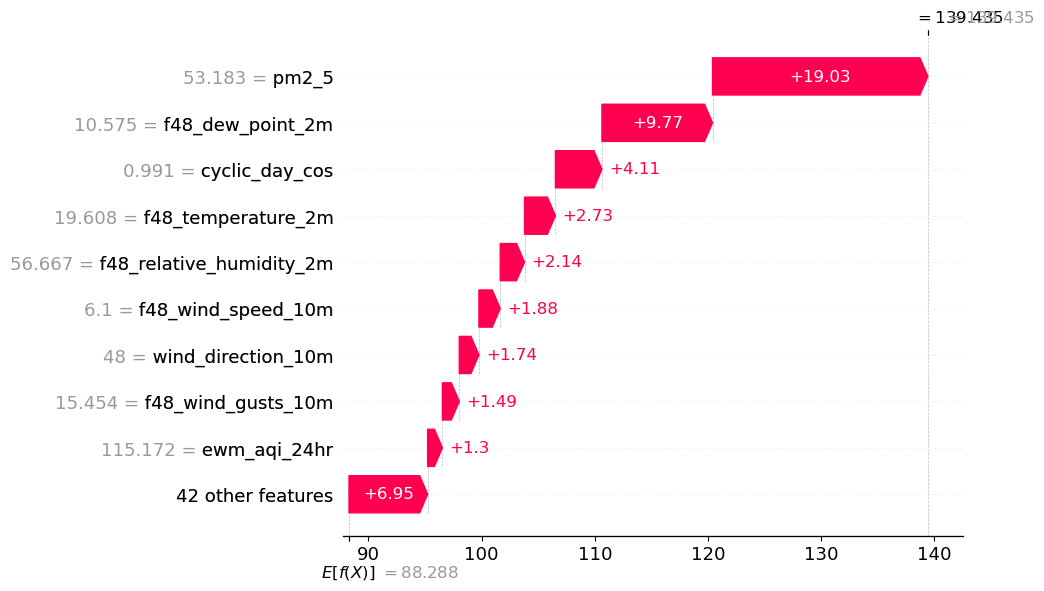

In [36]:
shap.plots.waterfall(shap_values[0])

### Beeswarm Plot

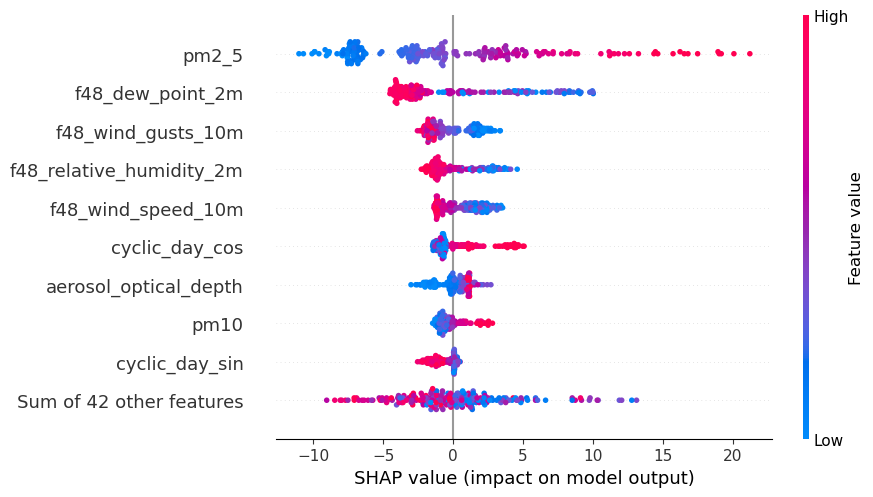

In [37]:
shap.plots.beeswarm(shap_values)

# Prediction Chart

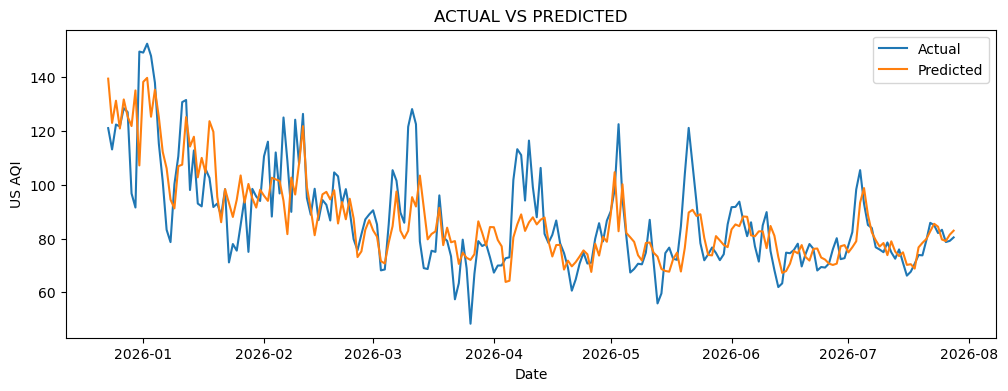

In [38]:
plt.figure(figsize=(12,4))
y_pred_tuned = best_random.predict(X_test1)
plt.plot(Y_test1.index, Y_test1.values, label="Actual")
plt.plot(Y_test1.index, y_pred_tuned, label="Predicted")
plt.legend(loc = "best")
plt.title("ACTUAL VS PREDICTED")
plt.ylabel("US AQI")
plt.xlabel("Date")
plt.show()